In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns
from matplotlib.lines import Line2D




In [76]:
intact = pd.read_csv('../data/master/intact.csv')
amputated = pd.read_csv('../data/master/amputated.csv')
intact_boxcox = pd.read_csv('../data/master/intact_boxcox.csv')
amputated_boxcox = pd.read_csv('../data/master/amputated_boxcox.csv')
intact_yeojohnson = pd.read_csv('../data/master/intact_yeojohnson.csv')
amputated_yeojohnson = pd.read_csv('../data/master/amputated_yeojohnson.csv')

# Comparación de estadísticas antes/después de cada transformación.

In [77]:
def compare_transform_stats(df_original, df_transformed, variable, n_channels=8):
    stats = []
    for stimulus in df_original['stimulus'].unique():
        df_orig_stim = df_original[df_original['stimulus'] == stimulus]
        df_trans_stim = df_transformed[df_transformed['stimulus'] == stimulus]
        
        for ch in range(1, n_channels + 1):
            col = f'Channel {ch}_{variable}'
            
            orig = df_orig_stim[col]
            trans = df_trans_stim[col]
            
            skew_orig = round(orig.skew(), 3)
            skew_trans = round(trans.skew(), 3)
            
            if skew_orig != 0:
                pct_change = round((skew_trans - skew_orig) / abs(skew_orig) * 100, 1)
            else:
                pct_change = 0.0
            
            stats.append({
                'Stimulus': stimulus,
                'Channel': f'Channel {ch}',
                'Feature': variable,
                'Media_orig': round(orig.mean(), 3),
                'Media_trans': round(trans.mean(), 3),
                'Sesgo_orig': skew_orig,
                'Sesgo_trans': skew_trans,
                '% Cambio Sesgo': f'{pct_change:+.1f}%',
                'Varianza_orig': round(orig.var(), 3),
                'Varianza_trans': round(trans.var(), 3)
            })
    
    df_stats = pd.DataFrame(stats)
    return df_stats

In [78]:
def compare_all_features(df_original, df_transformed, features, transform_name, n_channels=8):
    """
    Ejecuta compare_transform_stats para cada feature, añade columna 'transformacion'
    y devuelve un DataFrame consolidado.
    
    Parameters
    ----------
    df_original : DataFrame con datos originales
    df_transformed : DataFrame con datos transformados
    features : lista de nombres de features (ej: ['VAR_STD', 'Range', ...])
    transform_name : str con nombre de la transformacion (ej: 'Box-Cox')
    n_channels : int, numero de canales (default 8)
    
    Returns
    -------
    DataFrame con columnas originales + 'transformacion'
    """
    dfs = []
    for feat in features:
        df_feat = compare_transform_stats(df_original, df_transformed, feat, n_channels)
        dfs.append(df_feat)
    
    df_all = pd.concat(dfs, ignore_index=True)
    df_all['transformacion'] = transform_name
    return df_all

In [79]:
def plot_skewness_boxplot_by_stimulus(df_comparacion, features):
    # 1. Obtener los estímulos únicos y ordenarlos
    stimuli = sorted(df_comparacion['Stimulus'].unique())
    
    # sharey=True para que todos compartan la misma escala fija
    fig, axes = plt.subplots(2, 4, figsize=(22, 12), sharey=True)
    axes = axes.flatten()
    
    colors = {'Yeo-Johnson': 'green', 'Box-Cox': 'blue'}
    
    for i, feat in enumerate(features):
        ax = axes[i]
        df_feat = df_comparacion[df_comparacion['Feature'] == feat]
        
        x_positions = np.arange(len(stimuli))
        width = 0.35
        
        for j, trans in enumerate(['Yeo-Johnson', 'Box-Cox']):
            df_trans = df_feat[df_feat['transformacion'] == trans]
            data = []
            
            for stim in stimuli:
                vals = df_trans[df_trans['Stimulus'] == stim]['Sesgo_trans'].values
                data.append(vals)
            
            ax.boxplot(data, positions=x_positions + j * width, widths=width,
                      patch_artist=True, boxprops=dict(facecolor=colors[trans], alpha=0.7))
        
        # --- CAMBIO SOLICITADO: Intervalo fijo de -1 a 2 ---
        ax.set_ylim(-1, 2)
        
        ax.set_xticks(x_positions + width / 2)
        ax.set_xticklabels(stimuli, fontsize=10, rotation=45)
        ax.set_title(feat, fontweight='bold', fontsize=14)
        
        if i % 4 == 0:
            ax.set_ylabel('Sesgo', fontsize=12)
            
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
    
    # --- AJUSTE DE LEYENDA GLOBAL ---
    legend_elements = [Patch(facecolor=c, alpha=0.7, label=t) 
                       for t, c in colors.items()]
    
    fig.legend(handles=legend_elements, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=14, frameon=False)
    
    plt.suptitle('Comparativa de Sesgo por Estímulo (Escala -1 a 2): Yeo-Johnson vs Box-Cox', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [80]:
def plot_all_skewness_stripplots(df_comparacion, features, n_channels=8):
    # 1. Crear la cuadrícula de 2x4
    # Mantenemos 22, 12 para consistencia con los otros plots
    fig, axes = plt.subplots(2, 4, figsize=(22, 12), sharey=False)
    axes = axes.flatten()
    
    # Preparar etiquetas de canales (CH1, CH2...) para el eje X
    df = df_comparacion.copy()
    df['Channel_Label'] = df['Channel'].apply(lambda x: x.replace('Channel ', 'CH'))
    
    # 2. Iterar sobre cada feature y su eje correspondiente
    for i, feat in enumerate(features):
        ax = axes[i]
        df_feat = df[df['Feature'] == feat]
        
        sns.stripplot(
            data=df_feat, 
            x='Channel_Label', 
            y='Sesgo_trans', 
            hue='transformacion', 
            palette={'Yeo-Johnson': 'green', 'Box-Cox': 'blue'},
            dodge=True, 
            jitter=True, 
            size=6, 
            alpha=0.6,
            ax=ax 
        )
        
        # Configuración de cada sub-gráfica
        ax.set_title(feat, fontweight='bold', fontsize=14)
        ax.set_xlabel('') 
        ax.set_ylabel('Sesgo' if i % 4 == 0 else '') 
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        
        # CORRECCIÓN: Borrar leyenda individual solo si existe
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # 3. Crear una única leyenda global para toda la figura
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Ubicación centrada en la parte superior, sin recuadro y en columnas
    fig.legend(handles, labels, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=14, frameon=False)
    
    plt.suptitle('Distribución de Sesgo por Canal y Feature — Yeo-Johnson vs Box-Cox', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    # Ajuste de margen para que la leyenda y el título no se solapen
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [81]:
def plot_skewness_histograms_with_orig(df_comparacion, features):
    # Colores consistentes
    colors = {'Original': 'grey', 'Box-Cox': 'blue', 'Yeo-Johnson': 'green'}
    
    fig, axes = plt.subplots(2, 4, figsize=(22, 12))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        
        # 1. Datos Originales
        df_orig = df_comparacion[(df_comparacion['Feature'] == feat) & 
                                 (df_comparacion['transformacion'] == 'Box-Cox')]
        vals_orig = df_orig['Sesgo_orig']
        
        sns.histplot(vals_orig, stat="percent", kde=True, color=colors['Original'], 
                     label='Original', ax=ax, alpha=0.3, line_kws={'linestyle': '--'})
        
        # 2. Datos Transformados
        for trans in ['Box-Cox', 'Yeo-Johnson']:
            vals_trans = df_comparacion[
                (df_comparacion['Feature'] == feat) & 
                (df_comparacion['transformacion'] == trans)
            ]['Sesgo_trans']
            
            sns.histplot(vals_trans, stat="percent", kde=True, color=colors[trans], 
                         label=trans, ax=ax, alpha=0.5)
        
        ax.set_title(feat, fontweight='bold', fontsize=14)
        ax.set_xlabel('Sesgo')
        ax.set_ylabel('Porcentaje (%)')
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        
        # CORRECCIÓN: Solo removemos la leyenda si realmente existe
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # --- AJUSTE DE LEYENDA GLOBAL ---
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Filtrar para evitar duplicados (Original, Box-Cox, Yeo-Johnson)
    unique_labels = ['Original', 'Box-Cox', 'Yeo-Johnson']
    filtered_handles = [h for h, l in zip(handles, labels) if l in unique_labels]
    
    fig.legend(filtered_handles, unique_labels, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=14, frameon=False)
    
    plt.suptitle('Comparativa de Distribución del Sesgo: Original vs Transformados', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()


In [82]:
def plot_skewness_histograms(df_comparacion, features):
    # Colores consistentes
    colors = {'Box-Cox': 'blue', 'Yeo-Johnson': 'green'}
    
    # Ajustamos la figura para dejar espacio a la leyenda arriba
    fig, axes = plt.subplots(2, 4, figsize=(22, 12))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        
        # Graficar cada transformación
        for trans, color in colors.items():
            vals_trans = df_comparacion[
                (df_comparacion['Feature'] == feat) & 
                (df_comparacion['transformacion'] == trans)
            ]['Sesgo_trans']
            
            # Usamos sns.histplot con stat="percent" para el eje Y
            sns.histplot(vals_trans, stat="percent", kde=True, color=color, 
                         label=trans, ax=ax, alpha=0.5)
        
        # Configuración estética de cada subplot
        ax.set_title(feat, fontweight='bold', fontsize=14)
        ax.set_xlabel('Sesgo')
        ax.set_ylabel('Porcentaje (%)')
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        
        # CORRECCIÓN: Borrar leyenda individual solo si existe
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # --- AJUSTE DE LEYENDA GLOBAL ---
    # Extraemos los handles y labels del primer eje
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Filtramos para mostrar solo Box-Cox y Yeo-Johnson
    unique_labels = ['Box-Cox', 'Yeo-Johnson']
    filtered_handles = [h for h, l in zip(handles, labels) if l in unique_labels]
    
    # Ubicación centrada en la parte superior
    fig.legend(filtered_handles, unique_labels, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=14, frameon=False)
    
    plt.suptitle('Distribución del Sesgo — Box-Cox vs Yeo-Johnson', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    # Ajuste de margen para la leyenda y el título
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()

In [83]:
def plot_skewness_reduction_by_channel(df_comparacion, features, n_channels=8):
    df = df_comparacion.copy()
    
    # 1. Calcular % de reducción del sesgo
    df['Reducción (%)'] = np.where(
        df['Sesgo_orig'] != 0,
        ((df['Sesgo_orig'] - df['Sesgo_trans']) / df['Sesgo_orig'].abs()) * 100,
        0
    )
    
    # Ajustamos la figura para dejar espacio a la leyenda arriba
    fig, axes = plt.subplots(2, 4, figsize=(22, 12))
    axes = axes.flatten()
    
    colors = {'Box-Cox': 'blue', 'Yeo-Johnson': 'green'}
    
    for ch_idx in range(n_channels):
        ax = axes[ch_idx]
        channel = f'Channel {ch_idx + 1}'
        
        df_ch = df[df['Channel'] == channel]
        df_avg = df_ch.groupby(['Feature', 'transformacion'])['Reducción (%)'].mean().unstack()
        
        # Asegurar que estén todos los features solicitados
        df_avg = df_avg.reindex(features)
        
        x = np.arange(len(features))
        width = 0.35
        
        for j, trans in enumerate(['Box-Cox', 'Yeo-Johnson']):
            if trans in df_avg.columns:
                bars = ax.bar(x + j * width, df_avg[trans], width, 
                              label=trans, color=colors[trans], alpha=0.7)
                
                # Etiquetas de valor sobre cada barra
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.0f}%', ha='center', va='bottom', fontsize=8)
        
        ax.set_title(f'{channel}', fontweight='bold', fontsize=14)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Reducción (%)')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        
        # ELIMINADO: ax.legend() ya no está aquí para evitar repeticiones
    
    # --- AJUSTE DE LEYENDA GLOBAL ---
    # Creamos la leyenda usando Patch para que sea consistente con los colores
    legend_elements = [Patch(facecolor=c, alpha=0.7, label=t) 
                       for t, c in colors.items()]
    
    fig.legend(handles=legend_elements, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=14, frameon=False)
    
    plt.suptitle('Reducción de Sesgo por Canal y Feature', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    # Ajuste de margen para la leyenda y el título
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()


In [84]:
def plot_skewness_scatter(df_comparacion, features, n_channels=8):
    # Aumentamos el tamaño para dar espacio a la leyenda y mejorar legibilidad
    fig, axes = plt.subplots(2, 4, figsize=(22, 12))
    axes = axes.flatten()
    
    colors = {'Box-Cox': 'blue', 'Yeo-Johnson': 'green'}
    
    for i, feat in enumerate(features):
        ax = axes[i]
        df_feat = df_comparacion[df_comparacion['Feature'] == feat]
        
        for trans, color in colors.items():
            df_trans = df_feat[df_feat['transformacion'] == trans]
            ax.scatter(df_trans['Sesgo_orig'], df_trans['Sesgo_trans'],
                      c=color, label=trans, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
        
        # Línea de referencia: sin cambio (y=x)
        lims = [min(df_feat['Sesgo_orig'].min(), df_feat['Sesgo_trans'].min()) - 0.5,
                max(df_feat['Sesgo_orig'].max(), df_feat['Sesgo_trans'].max()) + 0.5]
        ax.plot(lims, lims, 'k--', alpha=0.4, label='Sin cambio')
        
        # Línea de referencia: sesgo perfecto = 0
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.4)
        
        ax.set_title(feat, fontweight='bold', fontsize=14)
        ax.set_xlabel('Sesgo Original')
        ax.set_ylabel('Sesgo Transformado')
        ax.grid(alpha=0.3)
        
    
    # --- AJUSTE DE LEYENDA GLOBAL ---
    # Creamos elementos personalizados para la leyenda para que sea clara
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Box-Cox', markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Yeo-Johnson', markeredgecolor='black'),
        Line2D([0], [0], color='black', linestyle='--', label='Sin cambio'),
        Line2D([0], [0], color='red', linestyle='--', label='Sesgo 0')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', 
               bbox_to_anchor=(0.5, 0.95), ncol=4, fontsize=14, frameon=False)
    
    plt.suptitle('Sesgo Original vs Transformado', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    # Ajuste de margen para la leyenda y el título
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()

In [85]:
def plot_correlation_comparison(df_orig, df_trans, features, n_channels=8):
    cols = [f'Channel {ch}_{feat}' for feat in features for ch in range(1, n_channels + 1)]
    
    corr_orig = df_orig[cols].corr()
    corr_trans = df_trans[cols].corr()
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # vmin/vmax fijos e iguales en ambos → comparación justa
    sns.heatmap(corr_orig, annot=False, cmap='coolwarm', ax=axes[0], 
                center=0, vmin=-1, vmax=1)
    axes[0].set_title('Correlación Original', fontweight='bold')
    
    sns.heatmap(corr_trans, annot=False, cmap='coolwarm', ax=axes[1], 
                center=0, vmin=-1, vmax=1)
    axes[1].set_title('Correlación Transformada', fontweight='bold')
    
    # Bonus: imprime las métricas reales, no dependas solo del ojo
    mask = np.triu(np.ones_like(corr_orig, dtype=bool), k=1)
    print(f"Correlación promedio original:     {corr_orig.values[mask].mean():.4f}")
    print(f"Correlación promedio transformada:  {corr_trans.values[mask].mean():.4f}")
    
    plt.suptitle('Análisis de Integridad: Preservación de Correlaciones', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

In [86]:
features = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']

df_boxcox_intact = compare_all_features(intact, intact_boxcox, features, 'Box-Cox')
df_yeojohnson_intact = compare_all_features(intact, intact_yeojohnson, features, 'Yeo-Johnson')

df_comparacion = pd.concat([df_boxcox_intact, df_yeojohnson_intact], ignore_index=True)

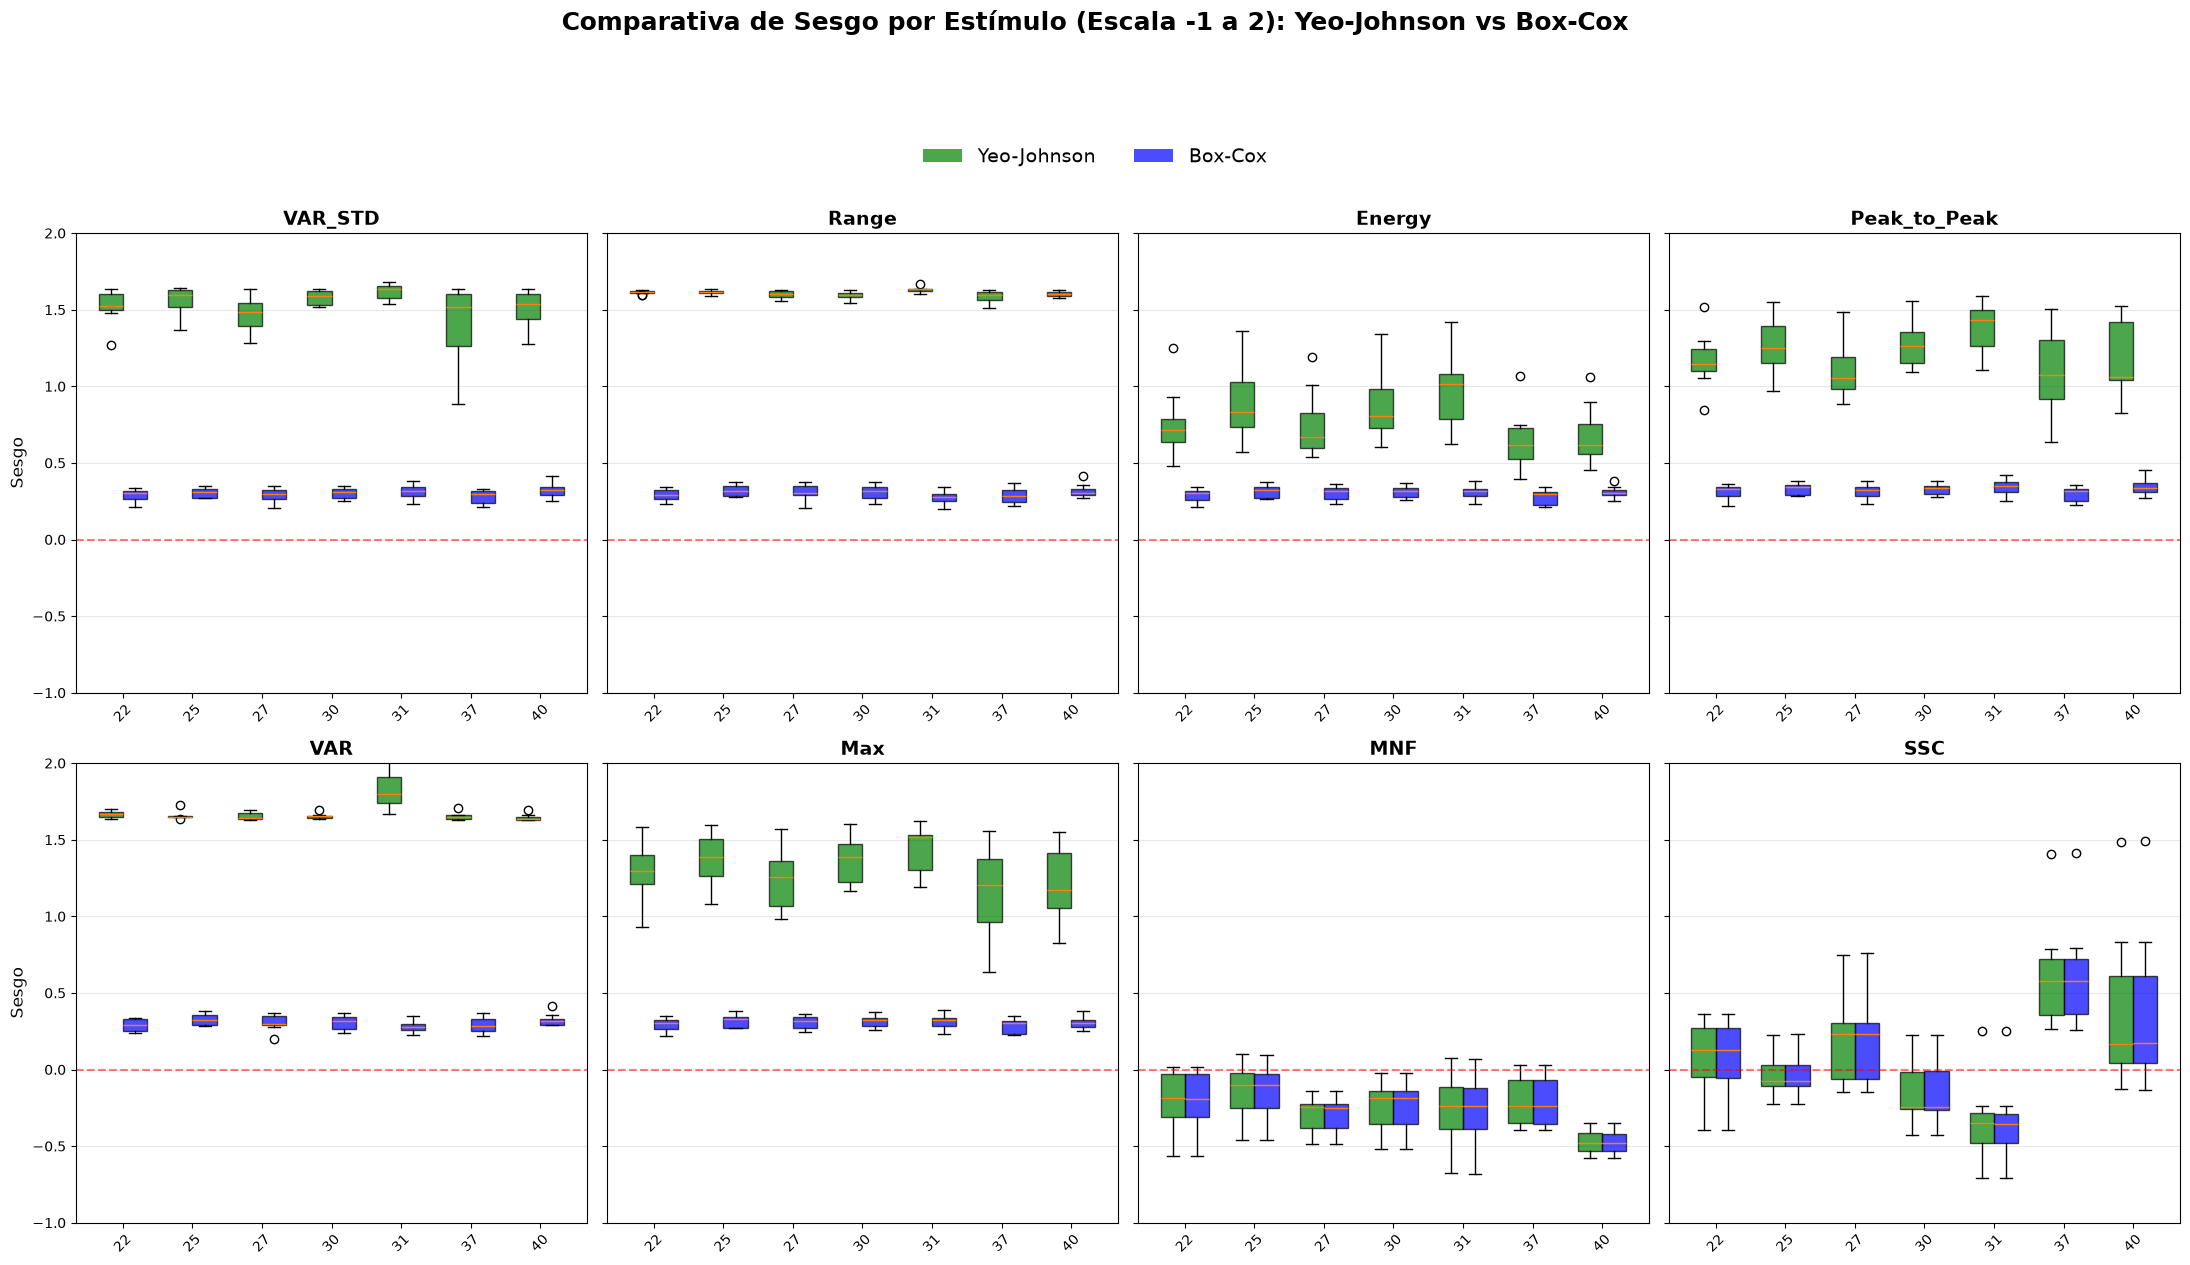

In [87]:
plot_skewness_boxplot_by_stimulus(df_comparacion, features)

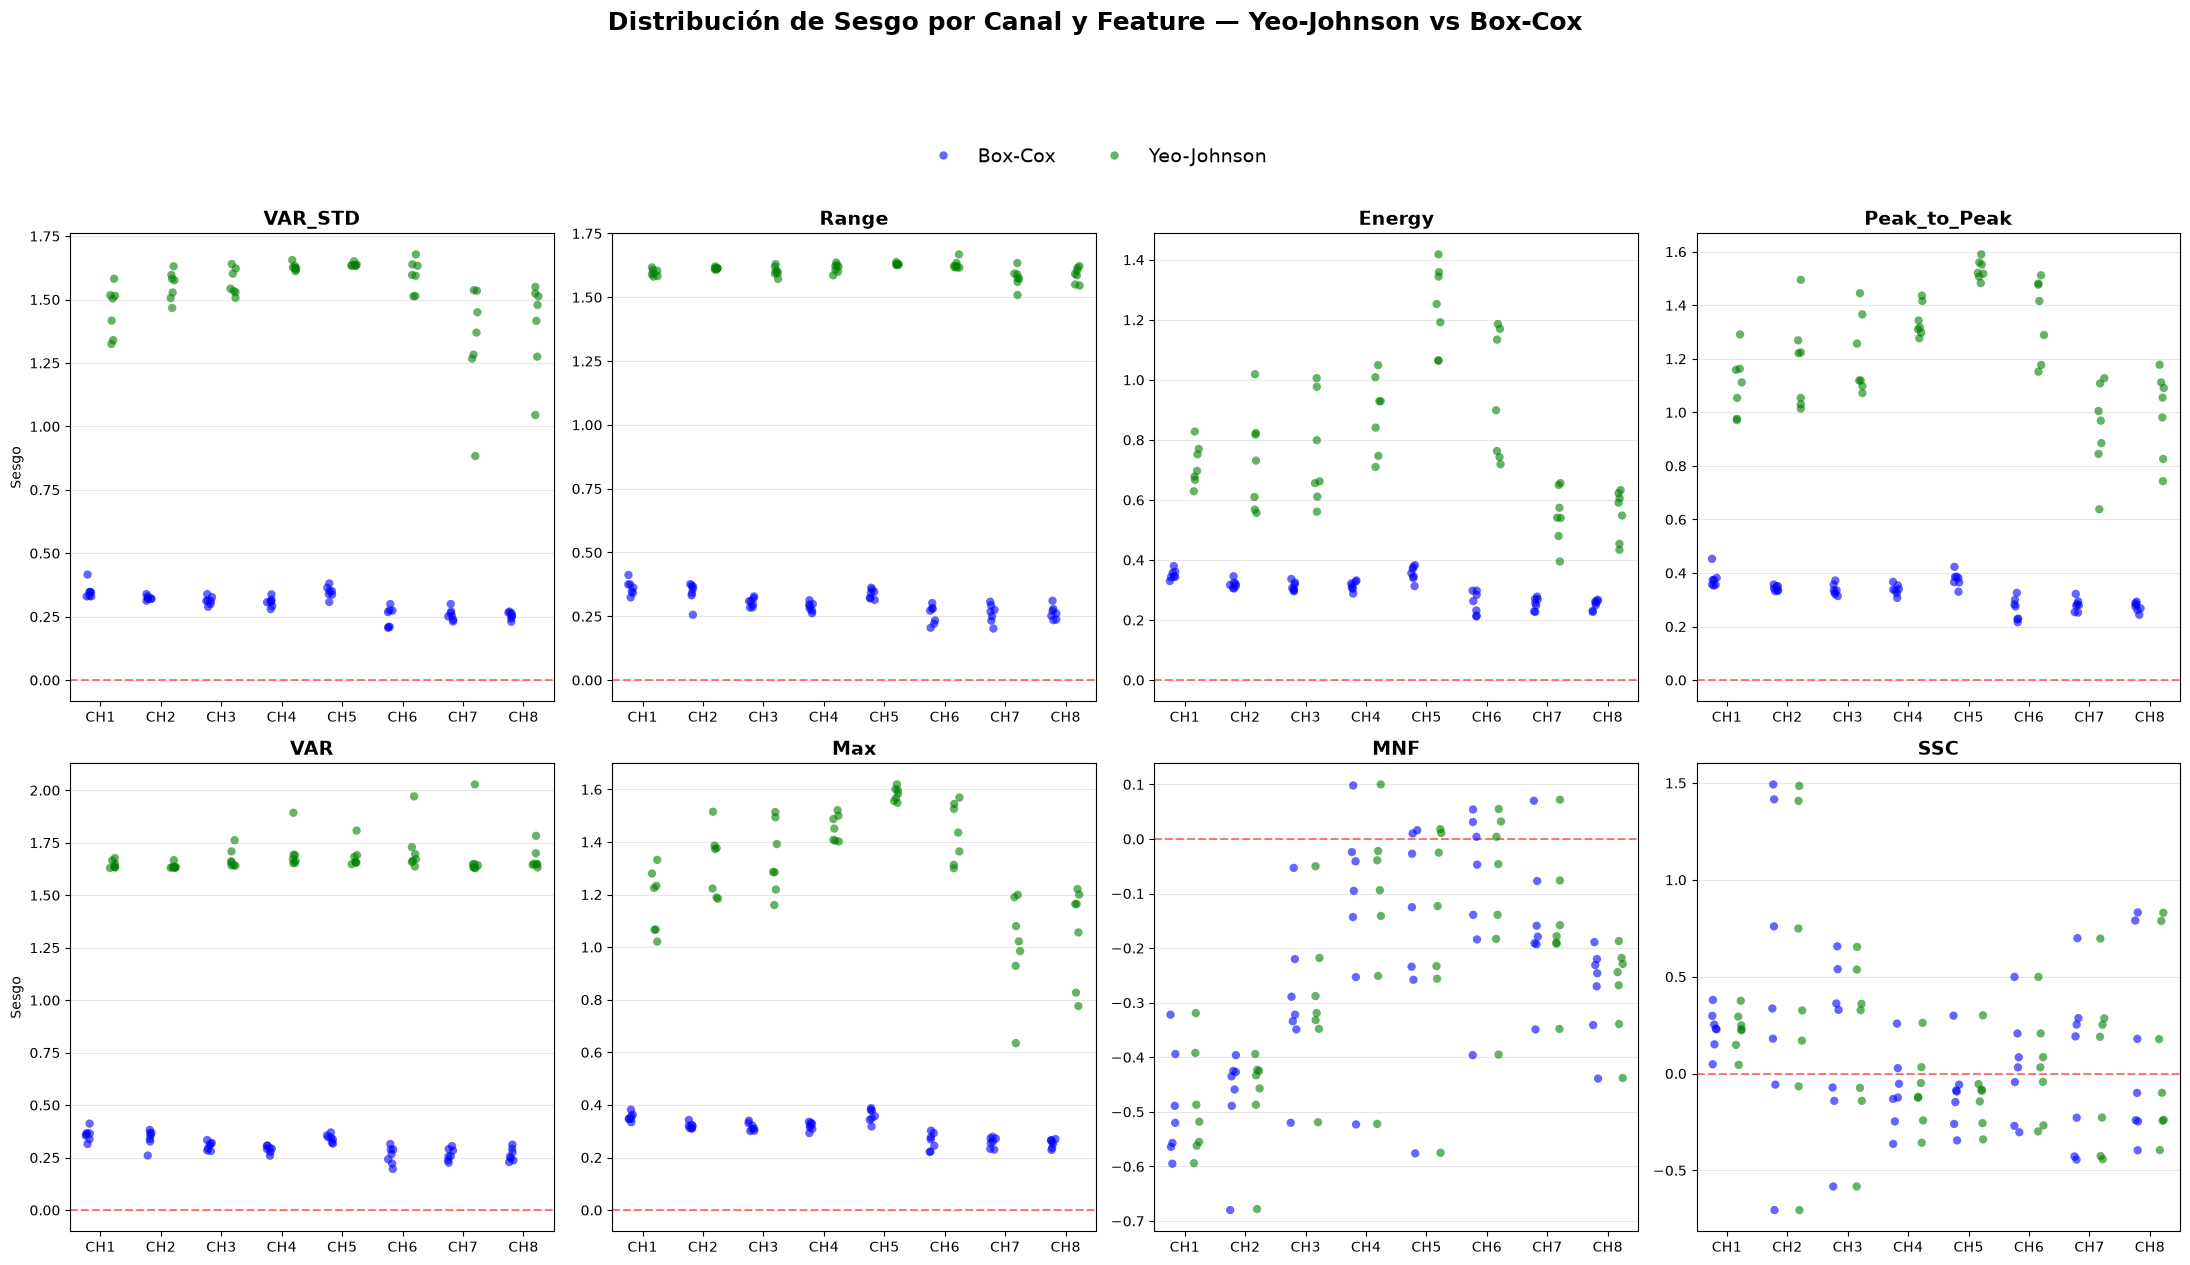

In [88]:
features_list = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
plot_all_skewness_stripplots(df_comparacion, features_list)

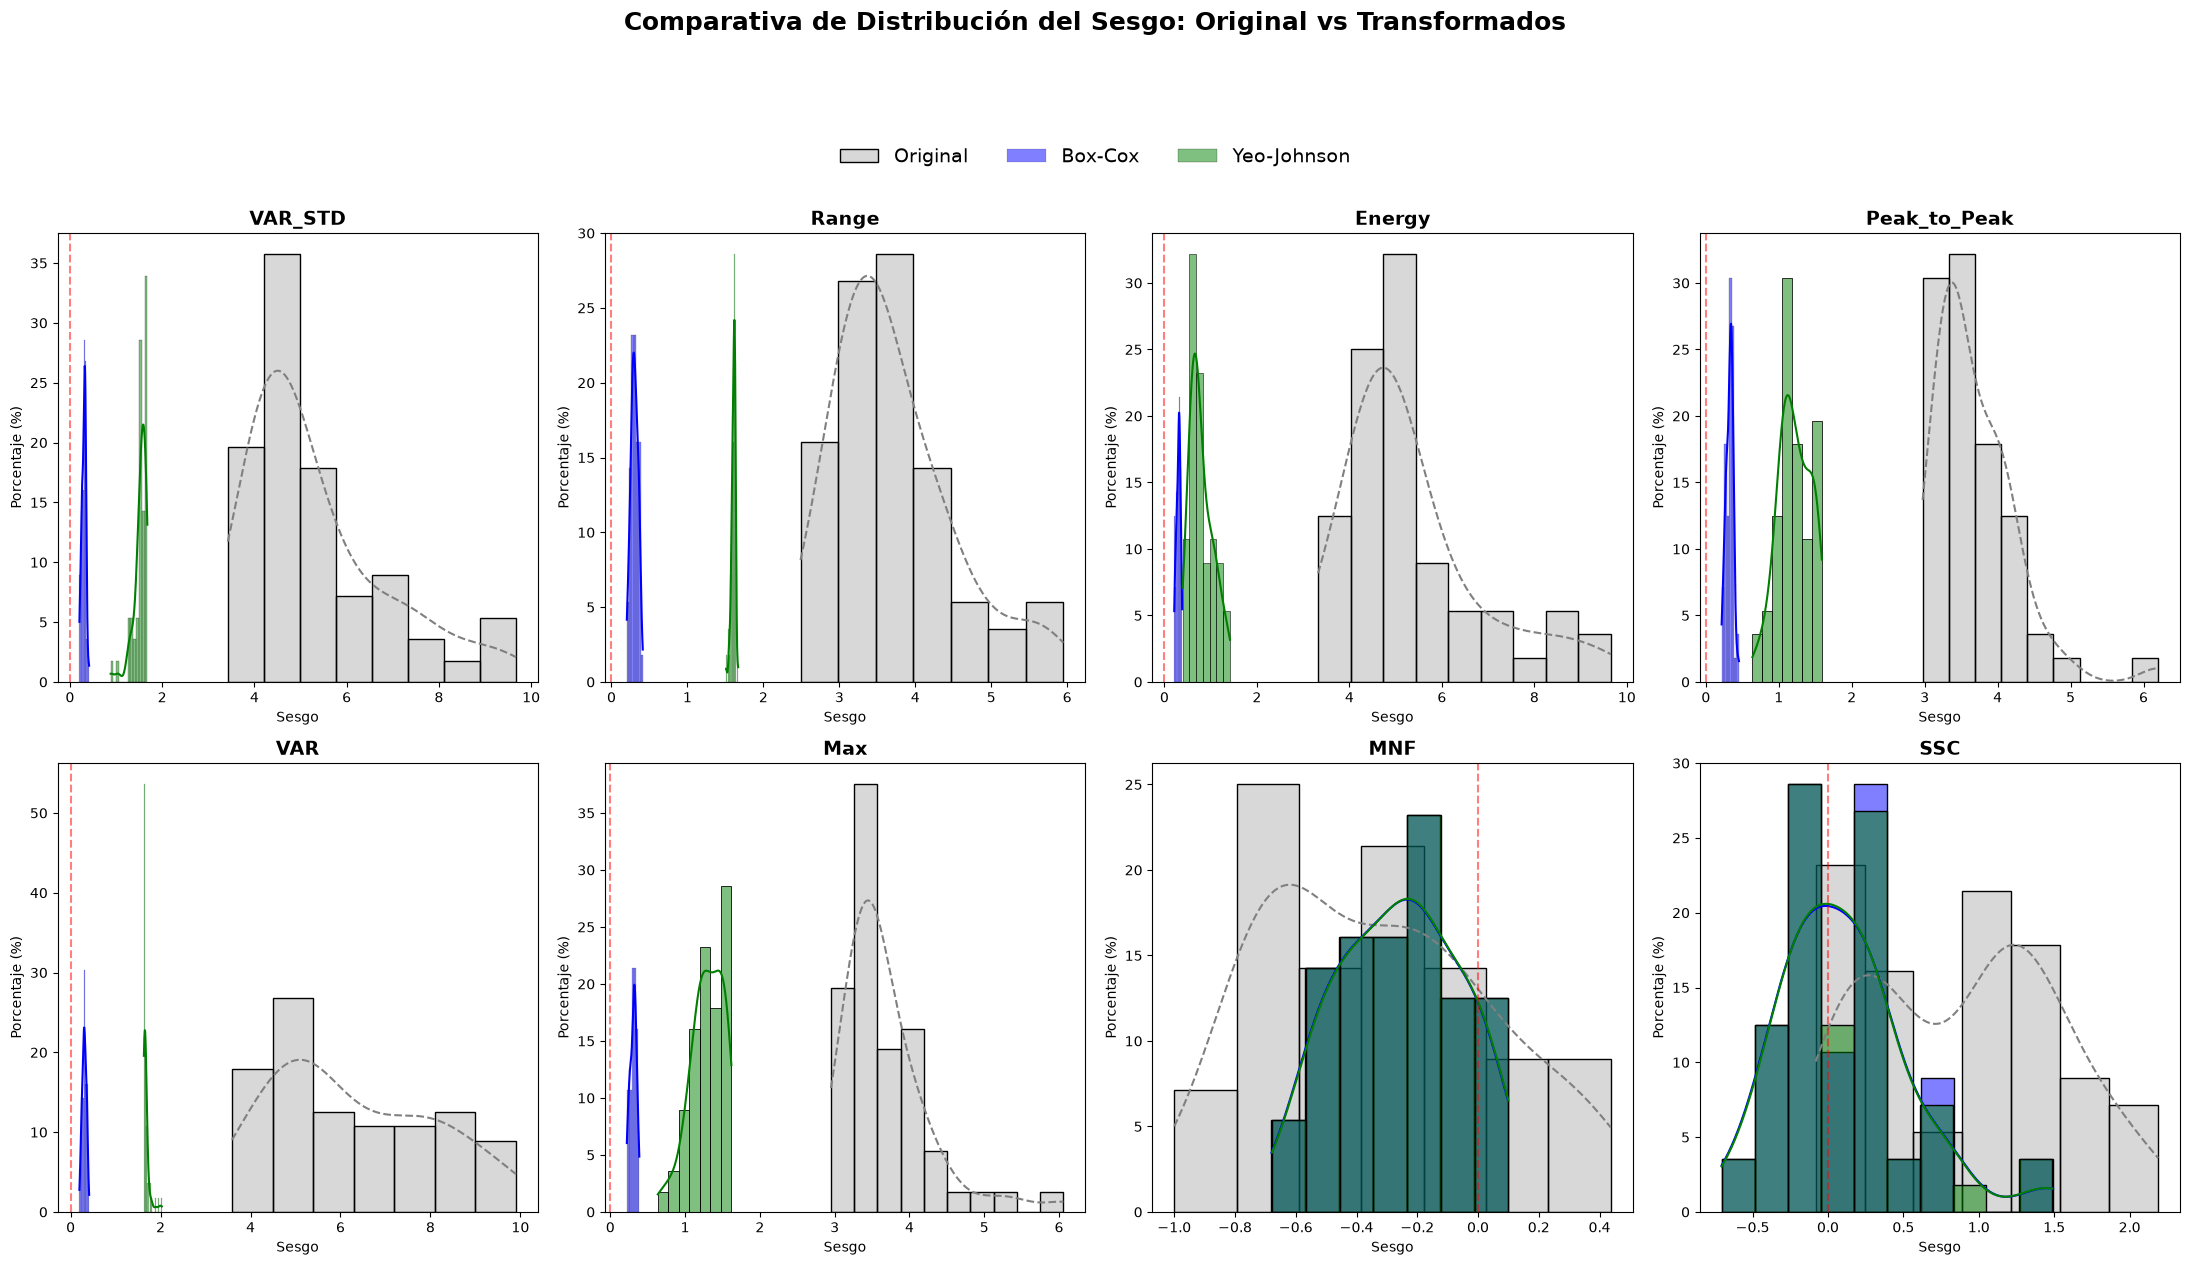

In [89]:
plot_skewness_histograms_with_orig(df_comparacion, features)

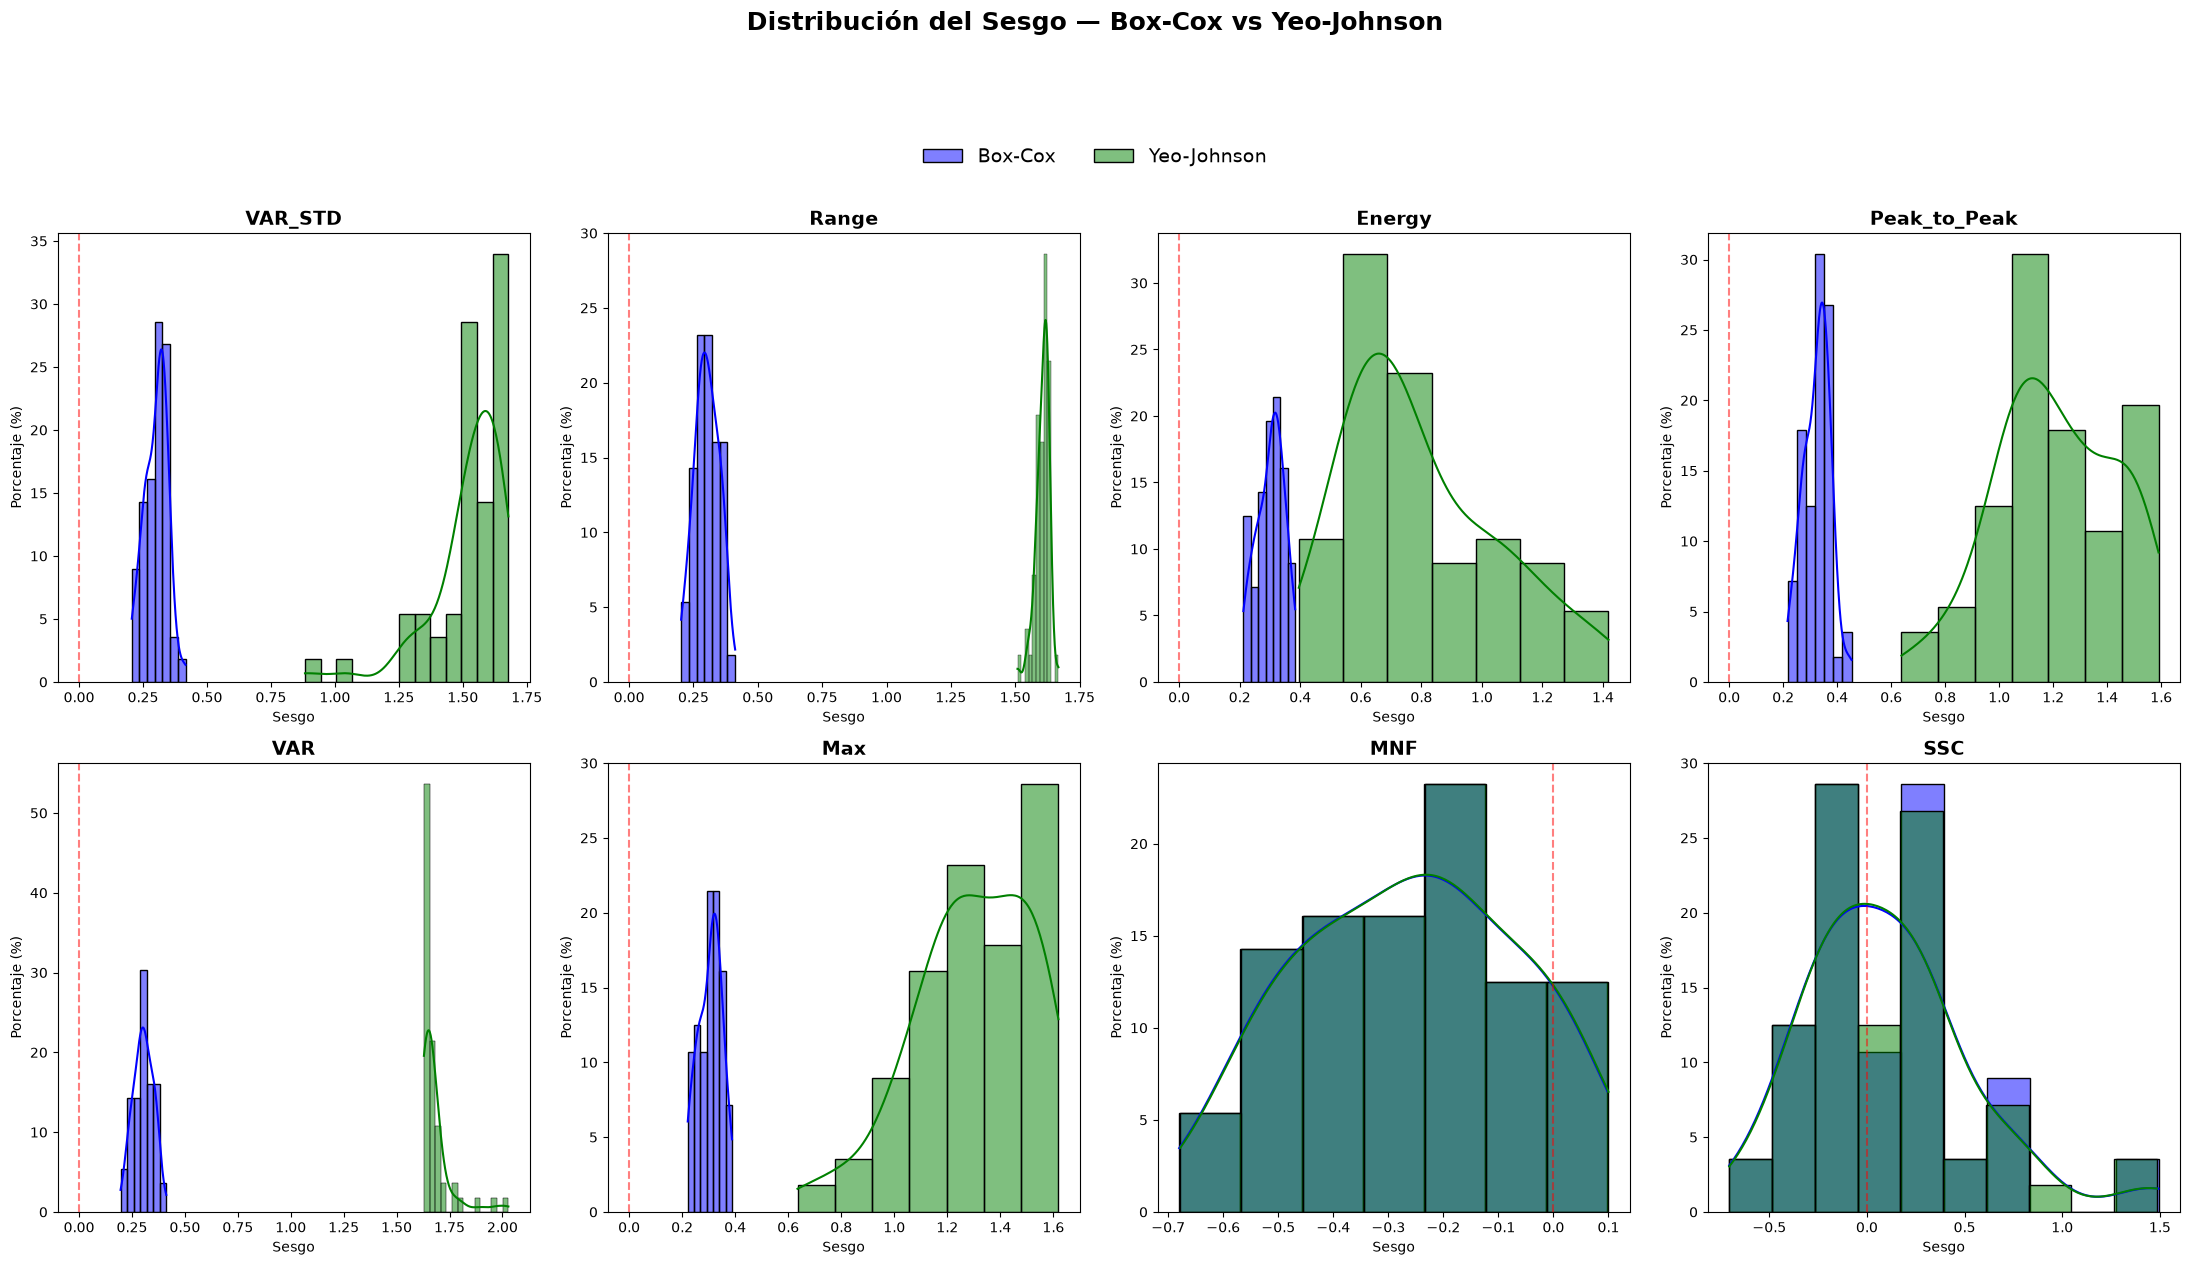

In [90]:
plot_skewness_histograms(df_comparacion, features)

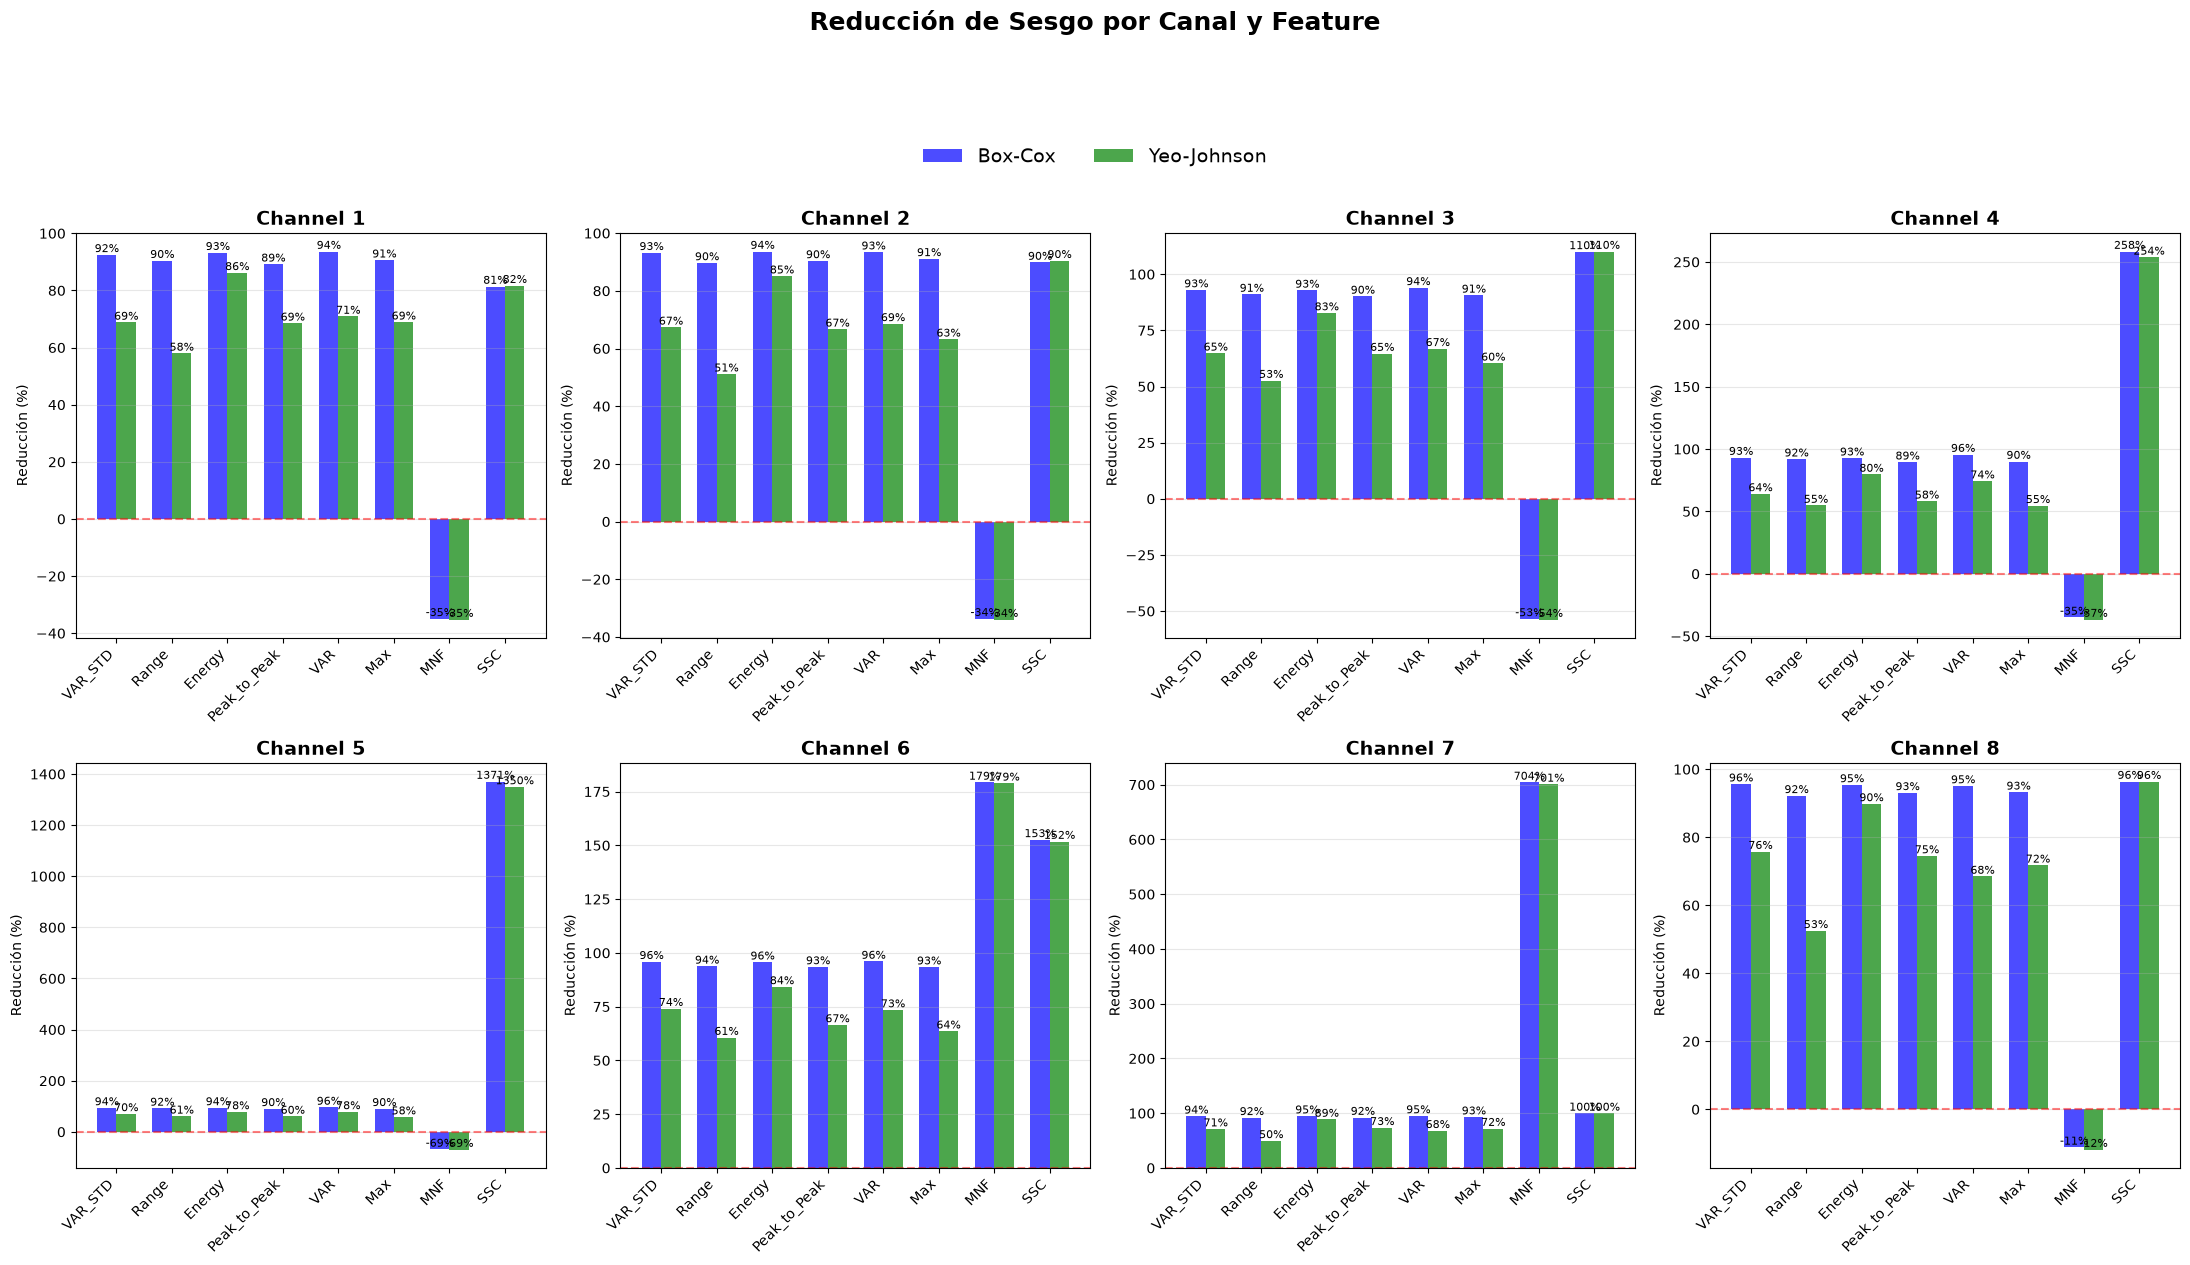

In [91]:
plot_skewness_reduction_by_channel(df_comparacion, features)

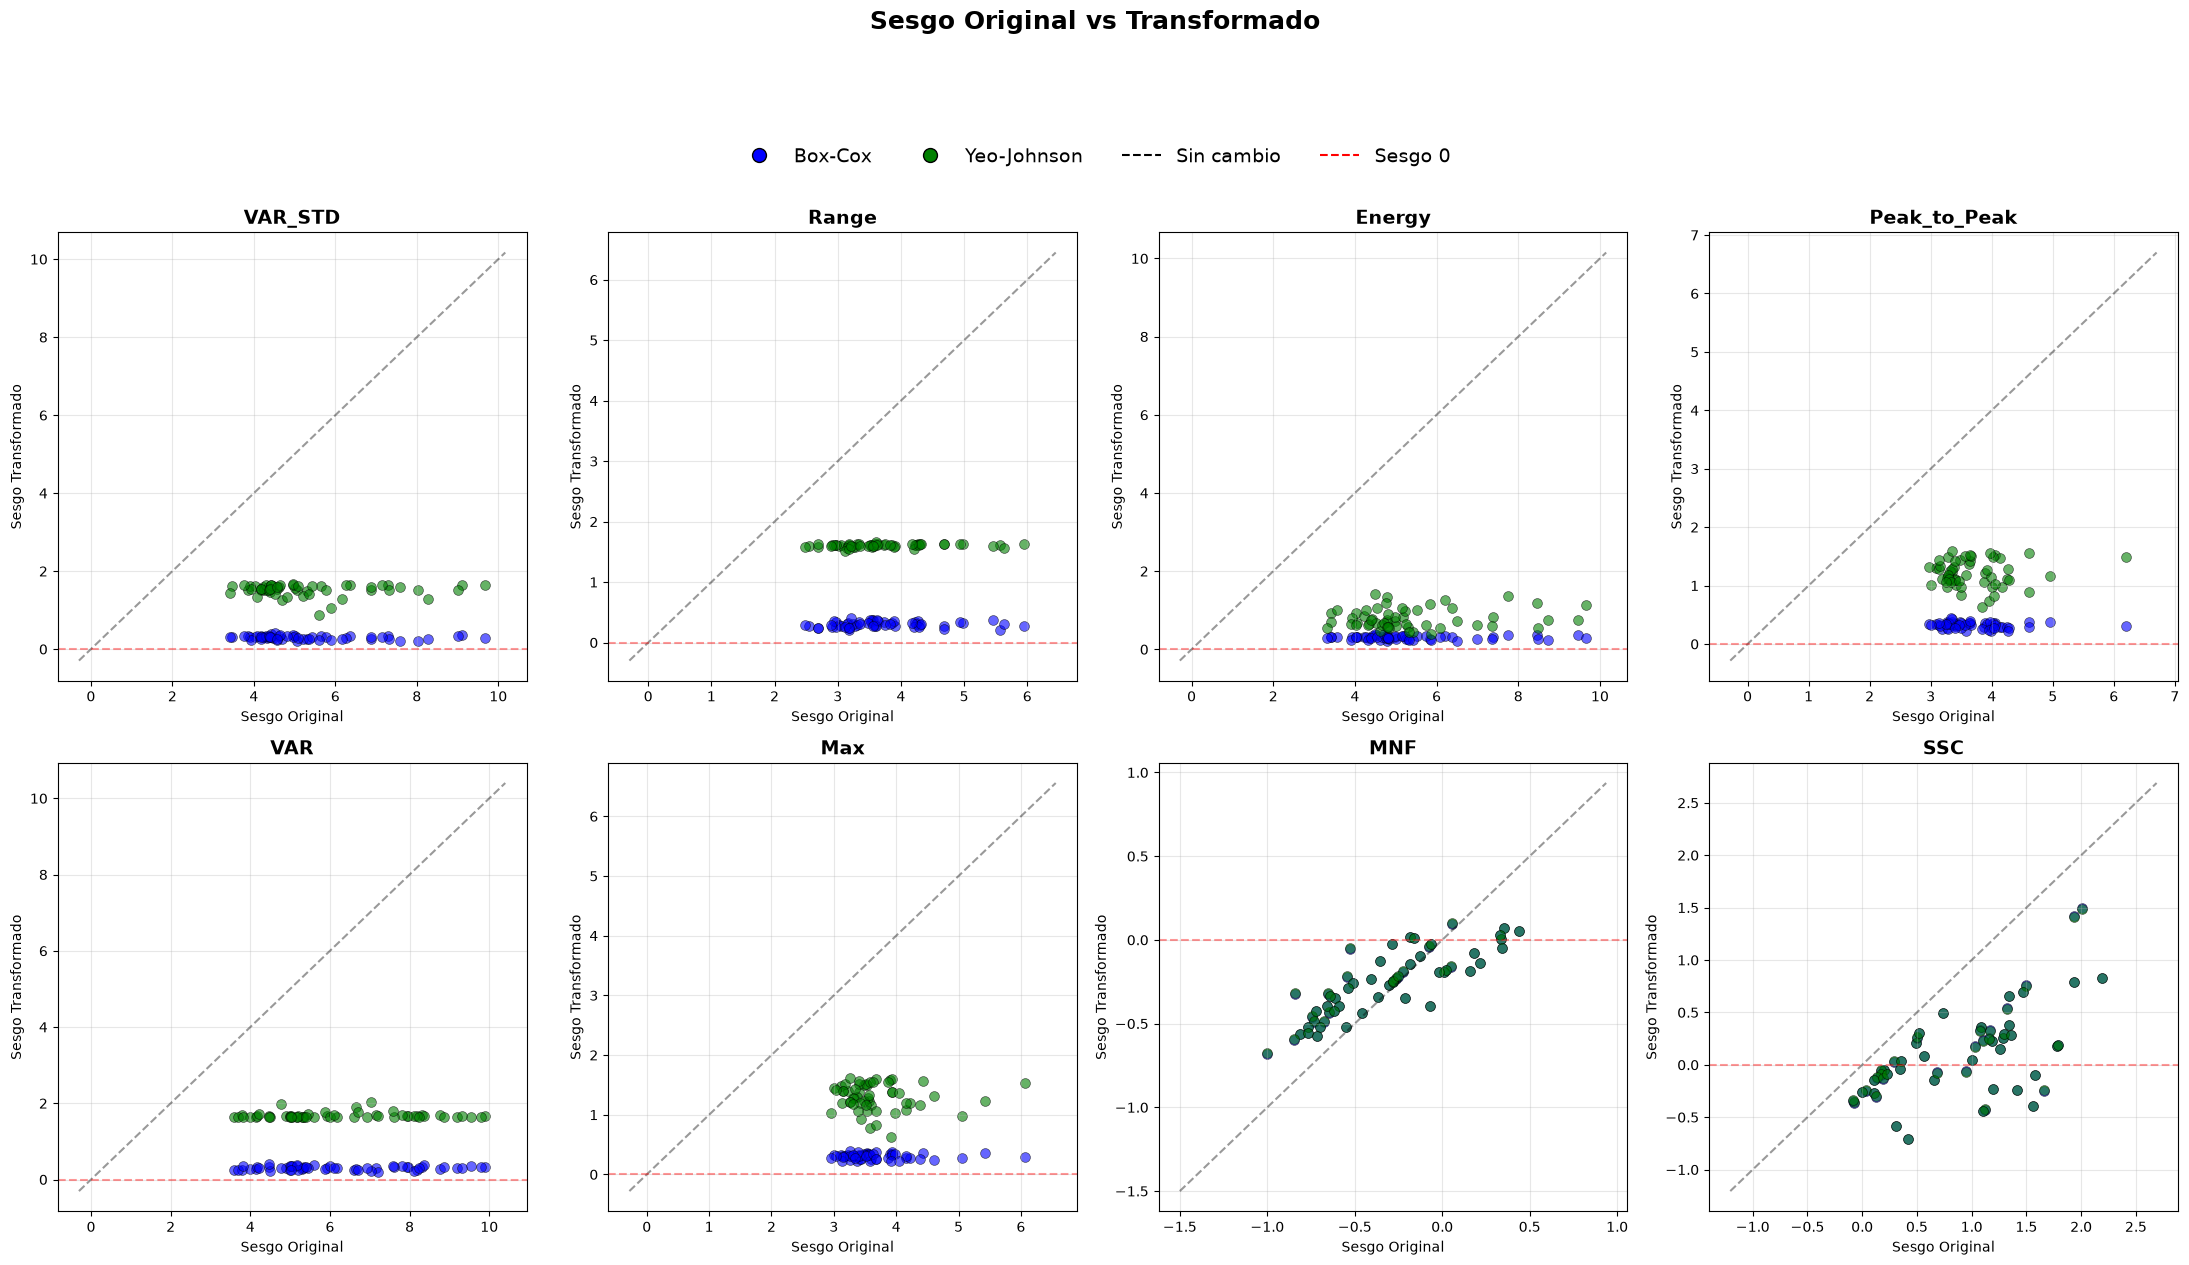

In [92]:
plot_skewness_scatter(df_comparacion, features)

Correlación promedio original:     0.4995
Correlación promedio transformada:  0.5056


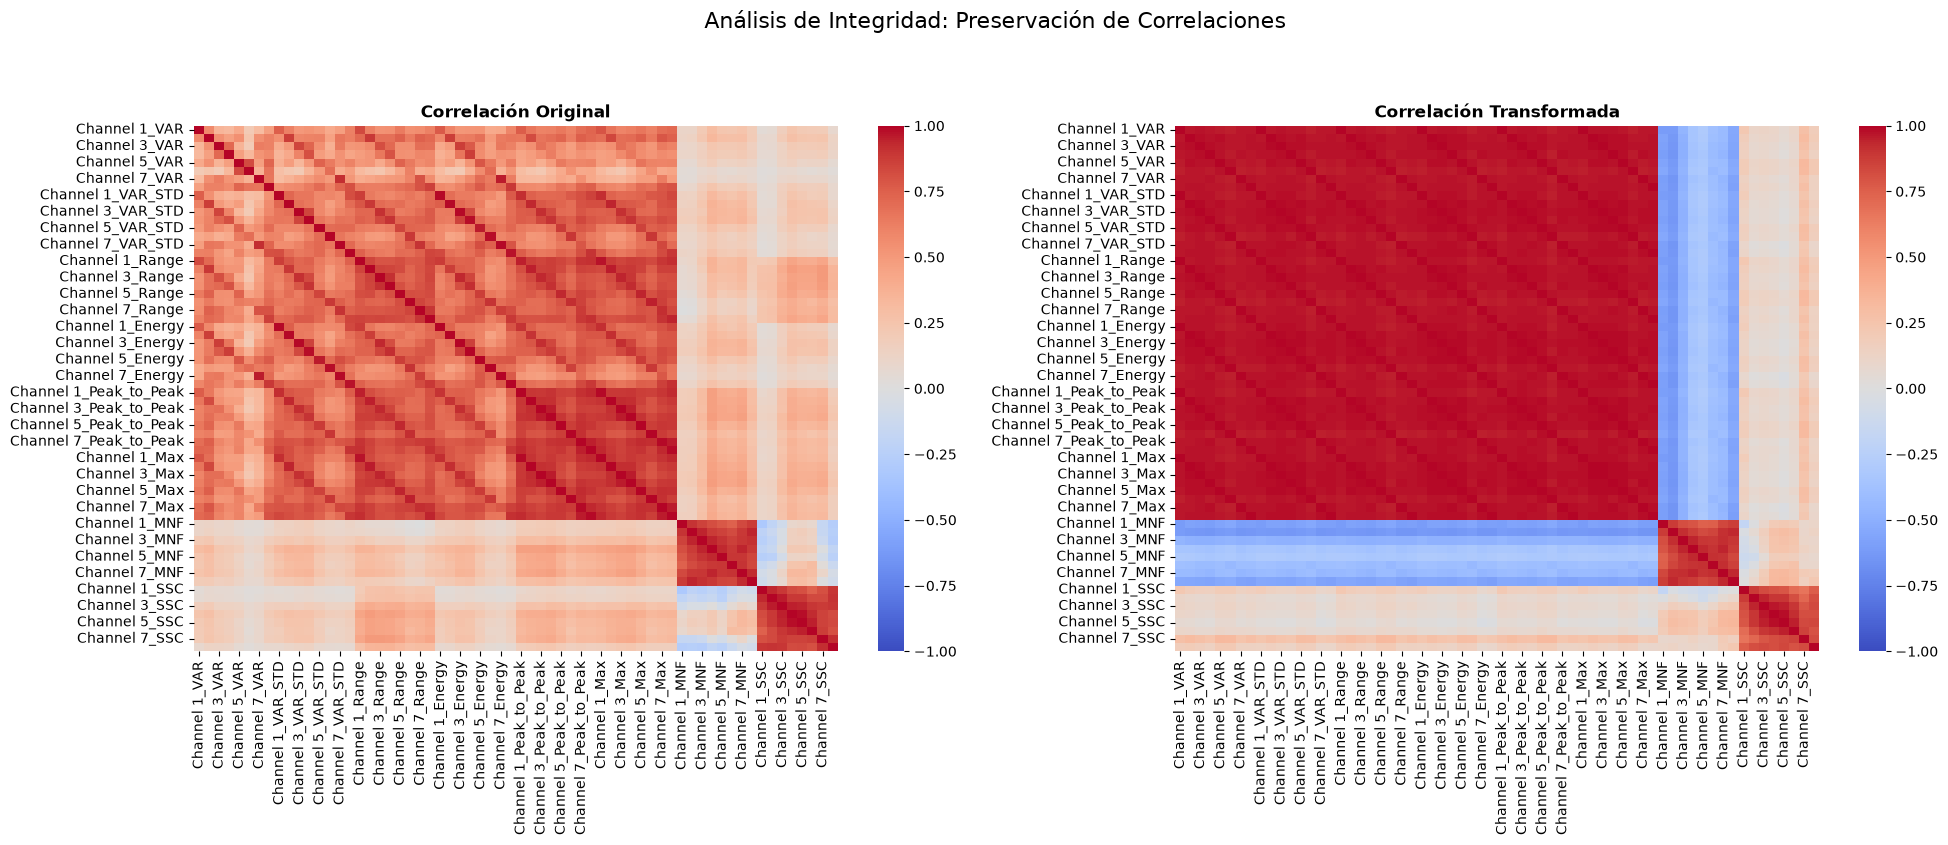

In [93]:
plot_correlation_comparison(intact, intact_boxcox, ['VAR', 'VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'Max', 'MNF', 'SSC'])

Correlación promedio original:     0.4995
Correlación promedio transformada:  0.6207


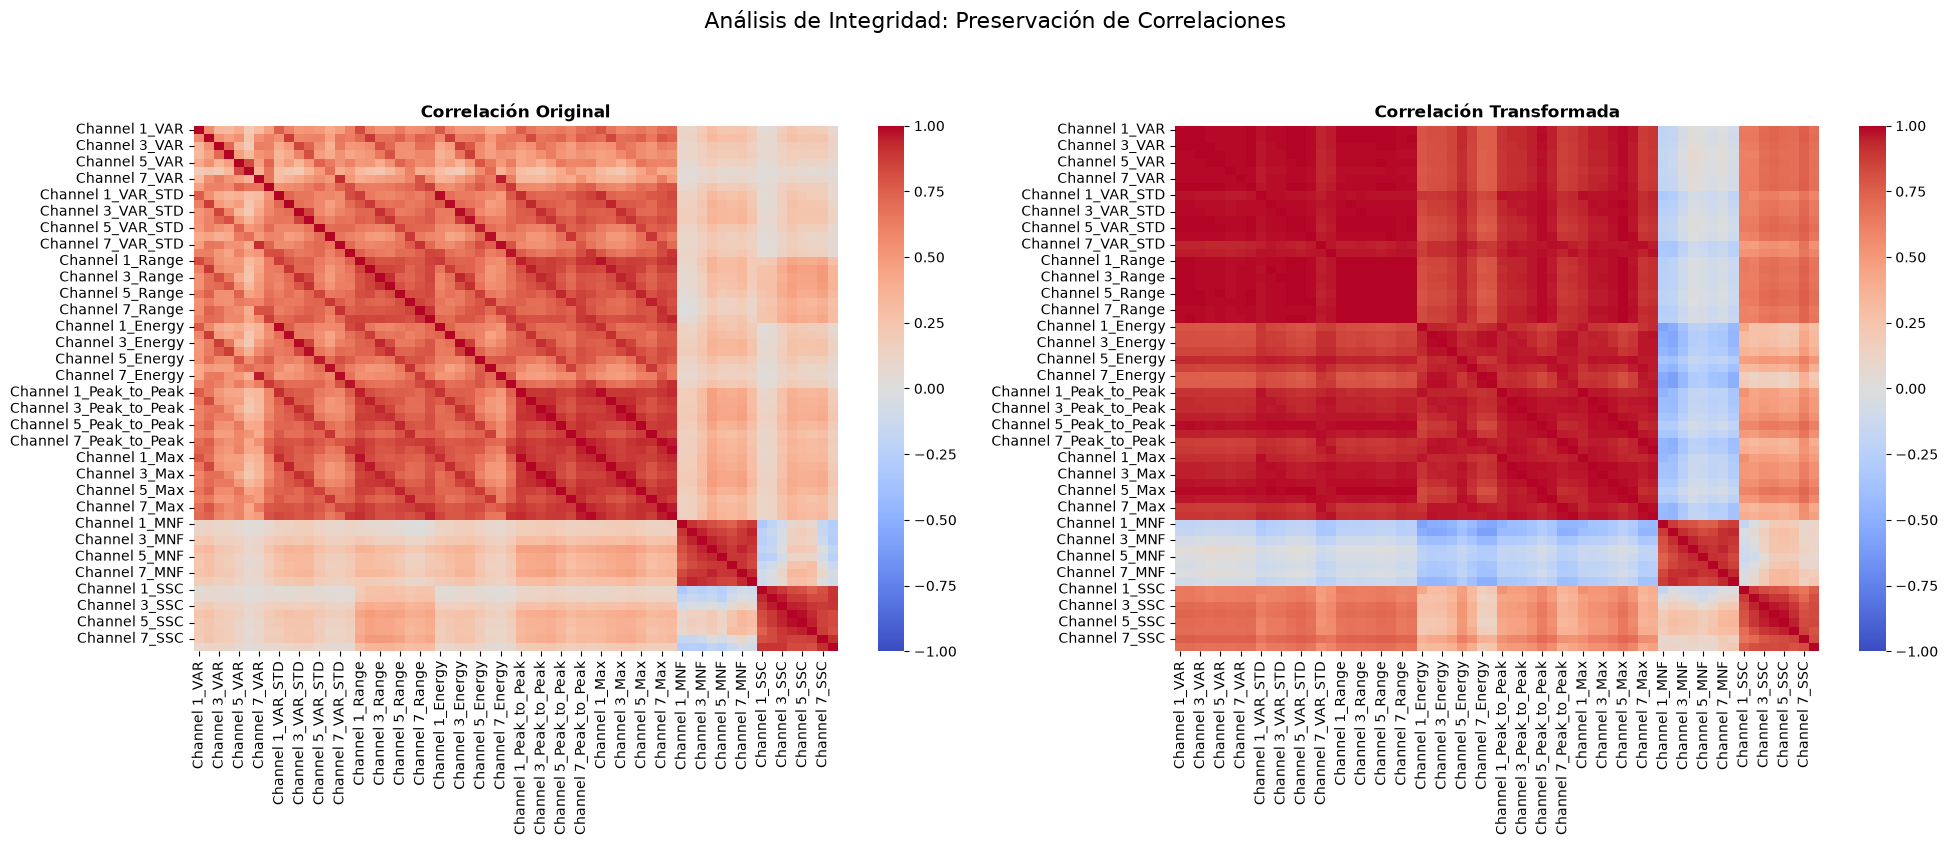

In [94]:
plot_correlation_comparison(intact,intact_yeojohnson, ['VAR', 'VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'Max', 'MNF', 'SSC'])